# Random Context Retrieval baseline - Stanford Cars

Notebook này triển khai method thứ 2 trong Table 2 của paper: **Random Context Ret.**

Ý tưởng: mỗi query image được ghép với một ảnh context lấy ngẫu nhiên từ candidate pool. Candidate pool lấy từ 20% train split, còn train/test vẫn dùng standard split có sẵn trong dataset. Notebook mặc định dùng `archive (13)` vì bản này có `anno_test.csv` kèm nhãn test, nên có thể in `test_accuracy`.

Output được lưu trong `OUT_PUT_DIR`, gồm `checkpoint_last.pt` sau mỗi epoch, final checkpoint, `training_history.csv`, `metrics.json`, `test_predictions.csv`, `candidate_pool.csv`, và `test_random_context_pairs.csv`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip -q /content/drive/MyDrive/archive\ \(13\).zip -d /content/archive\ \(13\)/

## 1. Cài thư viện

Chạy cell này trên Colab nếu môi trường chưa có đủ thư viện. Nếu chạy local đã cài sẵn thì có thể bỏ qua.


In [4]:
%pip -q install torch torchvision pandas pillow tqdm matplotlib torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.1 MB/s eta 0:00:00


In [10]:
!wget -c 'https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiNTFma3Jxa3l3bTl3MGpweHI2NndvNWZsIiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3ODkyOTc0MTJ9fX1dfQ__&Signature=sdowk%7EiiF6j8599sB9K5-M3sB%7Elq1be-oKP%7El7VBISEmjHEBPyCWw9Y2JD4oJY9LbXE313Q4ZgjX%7EXO3EiwGQZ3MZhfkZr0OXmADX8L%7E7XX%7E4mkVA1JSOkVzEa3Oj39gY%7E%7ER21%7EmJXEcFOZPMj%7EzGs-uxIh1xeRrfo-ZUqv3Yz7z7vUgn1OoDhu98kPnh8KT4MF1Gd6gcB4LogqWk3ooVScR6z8ECw50eawfY8lyUUzv%7E%7Em1QdstSU1k6HFhKFbuuogf0MyH7rzYScskxtGG95ke47CKn6CWSNbHLKhcLDfNx-XrN0A-xxis10rpJaMh2jBmxwohSr8XQlGVCBPWqQ__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=1749739516259745' \
  -O /content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth

--2026-09-12 16:39:02--  https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiNTFma3Jxa3l3bTl3MGpweHI2NndvNWZsIiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3ODkyOTc0MTJ9fX1dfQ__&Signature=sdowk%7EiiF6j8599sB9K5-M3sB%7Elq1be-oKP%7El7VBISEmjHEBPyCWw9Y2JD4oJY9LbXE313Q4ZgjX%7EXO3EiwGQZ3MZhfkZr0OXmADX8L%7E7XX%7E4mkVA1JSOkVzEa3Oj39gY%7E%7ER21%7EmJXEcFOZPMj%7EzGs-uxIh1xeRrfo-ZUqv3Yz7z7vUgn1OoDhu98kPnh8KT4MF1Gd6gcB4LogqWk3ooVScR6z8ECw50eawfY8lyUUzv%7E%7Em1QdstSU1k6HFhKFbuuogf0MyH7rzYScskxtGG95ke47CKn6CWSNbHLKhcLDfNx-XrN0A-xxis10rpJaMh2jBmxwohSr8XQlGVCBPWqQ__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=1749739516259745
Resolving dinov3.llamameta.net (dinov3.llamameta.net)... 52.85.132.100, 52.85.132.74, 52.85.132.54, ...
Connecting to dinov3.llamameta.net (dinov3.llamameta.net)|52.85.132.100|:443... connected.
HTTP request sent, aw

## 2. Import, cấu hình, dataset và candidate pool

Cell này đọc standard train/test split từ `archive (13)`. Không tách validation. Candidate pool được sample cố định từ 20% train split bằng `SEED`.


In [6]:
import json
import random
import subprocess
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)

PROJECT_DIR = Path.cwd()
DATASET_ROOT_CANDIDATES = [
    PROJECT_DIR / 'archive (13)',
    Path('F:/Documents/CODE/Python/cv_project/XLA/archive (13)'),
    Path('/content/archive (13)'),
    Path('/content/drive/MyDrive/archive (13)'),
]
DATASET_ROOT = next(
    (p for p in DATASET_ROOT_CANDIDATES if (p / 'anno_train.csv').is_file() and (p / 'anno_test.csv').is_file() and (p / 'names.csv').is_file()),
    DATASET_ROOT_CANDIDATES[0],
)
TRAIN_IMAGE_ROOT = DATASET_ROOT / 'car_data' / 'car_data' / 'train'
TEST_IMAGE_ROOT = DATASET_ROOT / 'car_data' / 'car_data' / 'test'

OUT_PUT_DIR = PROJECT_DIR / 'outputs' / 'baseline_random_context_ret_cars'
OUTPUT_DIR = OUT_PUT_DIR
OUT_PUT_DIR.mkdir(parents=True, exist_ok=True)

DINOV3_REPO_URL = 'https://github.com/facebookresearch/dinov3.git'
DINOV3_REPO_DIR = str(PROJECT_DIR / 'dinov3')
DINOV3_MODEL_NAME = 'dinov3_vits16'
DINOV3_WEIGHTS_URL = 'https://dl.fbaipublicfiles.com/dinov3/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth'
DINOV3_WEIGHTS = str(PROJECT_DIR / 'dinov3_vits16_pretrain_lvd1689m-08c60483.pth')
BACKBONE_NAME = DINOV3_MODEL_NAME
FEATURE_DIM = 384

IMAGE_SIZE = 256
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4
NUM_CLASSES = 196
TOP_K = 5
USE_BBOX_CROP = False
CANDIDATE_POOL_FRACTION = 0.20

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomResizedCrop((IMAGE_SIZE, IMAGE_SIZE), scale=(0.75, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])


def load_class_names(dataset_root):
    class_names = pd.read_csv(dataset_root / 'names.csv', header=None)[0].astype(str).tolist()
    if len(class_names) != NUM_CLASSES:
        raise ValueError(f'Expected {NUM_CLASSES} classes, got {len(class_names)}')
    return class_names


def load_annotations(dataset_root, split):
    df = pd.read_csv(
        dataset_root / f'anno_{split}.csv',
        header=None,
        names=['fname', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2', 'class_id_1based'],
    )
    df['class_id'] = df['class_id_1based'].astype(int) - 1
    df['split'] = split
    df['row_id'] = np.arange(len(df))
    return df


def attach_image_paths(df, image_root):
    image_index = {path.name: path for path in sorted(Path(image_root).rglob('*.jpg'))}
    missing = [fname for fname in df['fname'] if fname not in image_index]
    if missing:
        raise FileNotFoundError(f'Thieu anh trong {image_root}, vi du: {missing[:5]}')
    out = df.copy()
    out['image_path'] = [str(image_index[fname]) for fname in out['fname']]
    return out


class_names = load_class_names(DATASET_ROOT)
train_df = attach_image_paths(load_annotations(DATASET_ROOT, 'train'), TRAIN_IMAGE_ROOT).reset_index(drop=True)
test_df = attach_image_paths(load_annotations(DATASET_ROOT, 'test'), TEST_IMAGE_ROOT).reset_index(drop=True)
NUM_CLASSES = len(class_names)

candidate_rng = np.random.default_rng(SEED)
candidate_pool_size = max(1, int(round(len(train_df) * CANDIDATE_POOL_FRACTION)))
candidate_pool_positions = np.sort(candidate_rng.choice(len(train_df), size=candidate_pool_size, replace=False))
candidate_df = train_df.iloc[candidate_pool_positions].reset_index(drop=True)

test_context_rng = np.random.default_rng(SEED + 10_000)
test_context_positions = test_context_rng.integers(0, len(candidate_df), size=len(test_df)).tolist()

candidate_df.to_csv(OUT_PUT_DIR / 'candidate_pool.csv', index=False)
test_pairs = []
for query_pos, context_pos in enumerate(test_context_positions):
    query = test_df.iloc[query_pos]
    context = candidate_df.iloc[context_pos]
    test_pairs.append({
        'query_fname': query['fname'],
        'query_class_id': int(query['class_id']),
        'query_car_name': class_names[int(query['class_id'])],
        'context_fname': context['fname'],
        'context_class_id': int(context['class_id']),
        'context_car_name': class_names[int(context['class_id'])],
        'context_pool_position': int(context_pos),
        'context_train_row_id': int(context['row_id']),
    })
test_context_pairs_df = pd.DataFrame(test_pairs)
test_context_pairs_df.to_csv(OUT_PUT_DIR / 'test_random_context_pairs.csv', index=False)

print('DATASET_ROOT:', DATASET_ROOT.resolve())
print('TRAIN_IMAGE_ROOT:', TRAIN_IMAGE_ROOT.resolve())
print('TEST_IMAGE_ROOT:', TEST_IMAGE_ROOT.resolve())
print('OUT_PUT_DIR:', OUT_PUT_DIR.resolve())
print(f'Standard train images: {len(train_df):,}')
print(f'Standard test images: {len(test_df):,}')
print(f'Candidate pool: {len(candidate_df):,}/{len(train_df):,} ({CANDIDATE_POOL_FRACTION:.0%})')
print(f'Train label range: {int(train_df.class_id.min())}..{int(train_df.class_id.max())}')
print(f'Test label range: {int(test_df.class_id.min())}..{int(test_df.class_id.max())}')
display(train_df.head())
display(test_context_pairs_df.head())


DEVICE: cuda
DATASET_ROOT: /content/archive (13)
TRAIN_IMAGE_ROOT: /content/archive (13)/car_data/car_data/train
TEST_IMAGE_ROOT: /content/archive (13)/car_data/car_data/test
OUT_PUT_DIR: /content/outputs/baseline_random_context_ret_cars
Standard train images: 8,144
Standard test images: 8,041
Candidate pool: 1,629/8,144 (20%)
Train label range: 0..195
Test label range: 0..195


,fname,bbox_x1,bbox_y1,bbox_x2,bbox_y2,class_id_1based,class_id,split,row_id,image_path
0,00001.jpg,39,116,569,375,14,13,train,0,/content/archive (13)/car_data/car_data/train/...
1,00002.jpg,36,116,868,587,3,2,train,1,/content/archive (13)/car_data/car_data/train/...
2,00003.jpg,85,109,601,381,91,90,train,2,/content/archive (13)/car_data/car_data/train/...
3,00004.jpg,621,393,1484,1096,134,133,train,3,/content/archive (13)/car_data/car_data/train/...
4,00005.jpg,14,36,133,99,106,105,train,4,/content/archive (13)/car_data/car_data/train/...


,query_fname,query_class_id,query_car_name,context_fname,context_class_id,context_car_name,context_pool_position,context_train_row_id
0,00001.jpg,180,Suzuki Aerio Sedan 2007,05232.jpg,191,Volkswagen Beetle Hatchback 2012,1038,5231
1,00002.jpg,102,Ferrari 458 Italia Convertible 2012,05439.jpg,67,Chevrolet TrailBlazer SS 2009,1082,5438
2,00003.jpg,144,Jeep Patriot SUV 2012,05905.jpg,118,GMC Savana Van 2012,1176,5904
3,00004.jpg,186,Toyota Camry Sedan 2012,03975.jpg,42,Bentley Continental GT Coupe 2007,782,3974
4,00005.jpg,184,Tesla Model S Sedan 2012,07275.jpg,190,Volkswagen Golf Hatchback 1991,1453,7274


## 3. Dataset pair và DataLoader

Mỗi sample trả về `(query_image, context_image, label, query_fname, context_fname, context_label)`. Train context thay đổi theo epoch nhưng deterministic; test context cố định để `test_accuracy` reproducible.


In [7]:
class StanfordCarsRandomContextDataset(Dataset):
    def __init__(self, annotations, candidate_annotations, query_transform, context_transform, seed=42, fixed_context_positions=None, crop_bbox=False):
        self.annotations = annotations.reset_index(drop=True).copy()
        self.candidate_annotations = candidate_annotations.reset_index(drop=True).copy()
        self.query_transform = query_transform
        self.context_transform = context_transform
        self.seed = int(seed)
        self.epoch = 0
        self.fixed_context_positions = fixed_context_positions
        self.crop_bbox = crop_bbox
        if fixed_context_positions is not None and len(fixed_context_positions) != len(self.annotations):
            raise ValueError('fixed_context_positions phai co cung do dai voi annotations')

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __len__(self):
        return len(self.annotations)

    def _open_image(self, row):
        image = Image.open(row['image_path']).convert('RGB')
        if self.crop_bbox:
            left = max(0, int(row['bbox_x1']) - 1)
            top = max(0, int(row['bbox_y1']) - 1)
            right = int(row['bbox_x2'])
            bottom = int(row['bbox_y2'])
            image = image.crop((left, top, right, bottom))
        return image

    def _sample_context_position(self, index):
        if self.fixed_context_positions is not None:
            return int(self.fixed_context_positions[index])
        rng = np.random.default_rng(self.seed + self.epoch * 1_000_003 + index)
        context_pos = int(rng.integers(0, len(self.candidate_annotations)))
        query_fname = self.annotations.iloc[index]['fname']
        if len(self.candidate_annotations) > 1 and self.candidate_annotations.iloc[context_pos]['fname'] == query_fname:
            context_pos = (context_pos + 1) % len(self.candidate_annotations)
        return context_pos

    def __getitem__(self, index):
        query_row = self.annotations.iloc[index]
        context_row = self.candidate_annotations.iloc[self._sample_context_position(index)]
        query_image = self.query_transform(self._open_image(query_row))
        context_image = self.context_transform(self._open_image(context_row))
        label = int(query_row['class_id'])
        context_label = int(context_row['class_id'])
        return query_image, context_image, label, query_row['fname'], context_row['fname'], context_label


train_dataset = StanfordCarsRandomContextDataset(train_df, candidate_df, train_transform, train_transform, seed=SEED, crop_bbox=USE_BBOX_CROP)
test_dataset = StanfordCarsRandomContextDataset(test_df, candidate_df, eval_transform, eval_transform, seed=SEED, fixed_context_positions=test_context_positions, crop_bbox=USE_BBOX_CROP)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

sample = train_dataset[0]
print('Sample tensors:', sample[0].shape, sample[1].shape)
print('Query/context:', sample[3], '->', sample[4])


Sample tensors: torch.Size([3, 256, 256]) torch.Size([3, 256, 256])
Query/context: 00001.jpg -> 00739.jpg


## 4. DINOv3 và model Random Context Ret.

Model nhận hai ảnh. Notebook ưu tiên token-level fusion: ghép patch tokens của query và context trước transformer blocks. Nếu DINOv3 hub model không expose API token-level tương thích, model sẽ fallback sang feature-level fusion `[q, c, |q-c|, q*c]` để notebook vẫn chạy được.


In [11]:
def ensure_dinov3_assets():
    repo_dir = Path(DINOV3_REPO_DIR)
    weights_path = Path(DINOV3_WEIGHTS)
    if not repo_dir.is_dir():
        try:
            print('Cloning DINOv3 repo to:', repo_dir)
            subprocess.run(['git', 'clone', '--depth', '1', DINOV3_REPO_URL, str(repo_dir)], check=True)
        except Exception as exc:
            print('Khong clone duoc DINOv3 repo. torch.hub se thu tai tu GitHub khi tao model.')
            print(type(exc).__name__ + ':', exc)
    else:
        print('DINOv3 repo da ton tai:', repo_dir)
    if not weights_path.is_file():
        print('Dang tai DINOv3 ViT-S/16 weights ve:', weights_path)
        urlretrieve(DINOV3_WEIGHTS_URL, weights_path)
    else:
        print('DINOv3 weights da ton tai:', weights_path)
    if weights_path.stat().st_size < 10 * 1024 * 1024:
        raise ValueError(f'File weight co ve bi loi hoac qua nho: {weights_path}')
    print('Weights size MB:', round(weights_path.stat().st_size / 1024**2, 2))


def resolve_dinov3_weights():
    path = Path(DINOV3_WEIGHTS)
    if not path.is_file():
        raise FileNotFoundError(f'Khong tim thay file: {path}')
    if path.stat().st_size < 10 * 1024 * 1024:
        raise ValueError('File weight bi rong hoac bi hong')
    return str(path)


class DinoV3RandomContextClassifier(nn.Module):
    def __init__(self, repo_dir, model_name, weights, num_classes, feature_dim=384, allow_feature_fallback=True):
        super().__init__()
        repo_dir = Path(repo_dir)
        source = 'local' if repo_dir.is_dir() else 'github'
        repo_or_dir = str(repo_dir) if repo_dir.is_dir() else 'facebookresearch/dinov3'
        self.backbone = torch.hub.load(repo_or_dir, model_name, source=source, weights=weights)
        self.feature_dim = feature_dim
        self.allow_feature_fallback = allow_feature_fallback
        self.supports_token_fusion = all(hasattr(self.backbone, attr) for attr in ['blocks', 'norm']) and (hasattr(self.backbone, 'prepare_tokens_with_masks') or hasattr(self.backbone, 'prepare_tokens'))
        self.active_fusion_mode = 'token_concat' if self.supports_token_fusion else 'feature_fusion'
        self.token_head = nn.Linear(feature_dim, num_classes)
        self.feature_head = nn.Sequential(nn.LayerNorm(feature_dim * 4), nn.Linear(feature_dim * 4, num_classes))

    def _extract_cls(self, features):
        if isinstance(features, dict):
            if 'x_norm_clstoken' in features:
                return features['x_norm_clstoken']
            if 'x_norm_cls_token' in features:
                return features['x_norm_cls_token']
            raise KeyError(f'Khong tim thay CLS token trong output keys: {list(features)}')
        return features

    def _encode_single(self, images):
        return self._extract_cls(self.backbone(images))

    def _prepare_tokens(self, images):
        if hasattr(self.backbone, 'prepare_tokens_with_masks'):
            try:
                return self.backbone.prepare_tokens_with_masks(images, None)
            except TypeError:
                return self.backbone.prepare_tokens_with_masks(images)
        if hasattr(self.backbone, 'prepare_tokens'):
            return self.backbone.prepare_tokens(images)
        raise AttributeError('Backbone khong expose prepare_tokens API')

    def _forward_token_concat(self, query_images, context_images):
        query_tokens = self._prepare_tokens(query_images)
        context_tokens = self._prepare_tokens(context_images)
        num_register_tokens = int(getattr(self.backbone, 'num_register_tokens', 0))
        num_prefix_tokens = 1 + num_register_tokens
        pair_tokens = torch.cat([query_tokens[:, :num_prefix_tokens], query_tokens[:, num_prefix_tokens:], context_tokens[:, num_prefix_tokens:]], dim=1)
        for block in self.backbone.blocks:
            pair_tokens = block(pair_tokens)
        pair_tokens = self.backbone.norm(pair_tokens)
        return self.token_head(pair_tokens[:, 0])

    def _forward_feature_fusion(self, query_images, context_images):
        q = self._encode_single(query_images)
        c = self._encode_single(context_images)
        pair = torch.cat([q, c, torch.abs(q - c), q * c], dim=1)
        return self.feature_head(pair)

    def forward(self, query_images, context_images):
        if self.supports_token_fusion:
            try:
                self.active_fusion_mode = 'token_concat'
                return self._forward_token_concat(query_images, context_images)
            except (AttributeError, TypeError, KeyError) as exc:
                if not self.allow_feature_fallback:
                    raise
                self.supports_token_fusion = False
                self.active_fusion_mode = 'feature_fusion'
                print('Token-level fusion khong kha dung, fallback sang feature fusion:', type(exc).__name__, exc)
        self.active_fusion_mode = 'feature_fusion'
        return self._forward_feature_fusion(query_images, context_images)


ensure_dinov3_assets()
model = DinoV3RandomContextClassifier(DINOV3_REPO_DIR, DINOV3_MODEL_NAME, resolve_dinov3_weights(), NUM_CLASSES, FEATURE_DIM).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == 'cuda')
checkpoint_path = OUT_PUT_DIR / 'final_random_context_ret_dinov3_vits16_cars.pt'
last_checkpoint_path = OUT_PUT_DIR / 'checkpoint_last.pt'
print('Initial fusion mode:', model.active_fusion_mode)
print(model)


DINOv3 repo da ton tai: /content/dinov3
DINOv3 weights da ton tai: /content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth
Weights size MB: 82.52
Downloading: "file:///content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vits16_pretrain_lvd1689m-08c60483.pth


100%|██████████| 82.5M/82.5M [00:00<00:00, 1.48GB/s]


Initial fusion mode: token_concat
DinoV3RandomContextClassifier(
  (backbone): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (rope_embed): RopePositionEmbedding()
    (blocks): ModuleList(
      (0-11): 12 x SelfAttentionBlock(
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (attn): SelfAttention(
          (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384

/tmp/ipykernel_1137/3942831875.py:105: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == 'cuda')


## 5. Train và lưu checkpoint sau từng epoch

Sau mỗi epoch, notebook lưu ngay `checkpoint_last.pt`. File này có cả model, optimizer, scheduler, history, candidate pool và fixed test context để resume hoặc kiểm tra lại.


In [12]:
def train_one_epoch(network, loader, epoch):
    network.train()
    loader.dataset.set_epoch(epoch)
    total_loss = 0.0
    all_targets = []
    all_predictions = []
    progress = tqdm(loader, desc=f'train epoch {epoch}', leave=False)
    for query_images, context_images, labels, *_ in progress:
        query_images = query_images.to(DEVICE, non_blocking=True)
        context_images = context_images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
            logits = network(query_images, context_images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * query_images.size(0)
        predictions = logits.argmax(dim=1)
        all_targets.extend(labels.detach().cpu().tolist())
        all_predictions.extend(predictions.detach().cpu().tolist())
        progress.set_postfix(loss=f'{loss.item():.4f}', fusion=network.active_fusion_mode)
    return {'loss': total_loss / len(loader.dataset), 'accuracy': float(np.mean(np.asarray(all_targets) == np.asarray(all_predictions)))}


def build_checkpoint_payload(epoch, history):
    return {
        'epoch': int(epoch),
        'method': 'Random Context Retrieval',
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history': list(history),
        'class_names': class_names,
        'architecture': BACKBONE_NAME,
        'feature_dim': FEATURE_DIM,
        'fusion_mode': getattr(model, 'active_fusion_mode', 'unknown'),
        'dinov3_model_name': DINOV3_MODEL_NAME,
        'dinov3_repo_dir': str(DINOV3_REPO_DIR),
        'dinov3_weights': str(resolve_dinov3_weights()),
        'dataset': 'Stanford Cars',
        'dataset_root': str(DATASET_ROOT),
        'standard_train_size': len(train_dataset),
        'standard_test_size': len(test_dataset),
        'image_size': IMAGE_SIZE,
        'mean': imagenet_mean,
        'std': imagenet_std,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'seed': SEED,
        'use_bbox_crop': USE_BBOX_CROP,
        'candidate_pool_fraction': CANDIDATE_POOL_FRACTION,
        'candidate_pool_size': len(candidate_df),
        'candidate_pool_positions': [int(x) for x in candidate_pool_positions],
        'test_context_positions': [int(x) for x in test_context_positions],
        'pretraining': 'DINOv3',
    }


RESUME_FROM_LAST_CHECKPOINT = False
history = []
start_epoch = 1
OUT_PUT_DIR.mkdir(parents=True, exist_ok=True)

if RESUME_FROM_LAST_CHECKPOINT and last_checkpoint_path.is_file():
    saved_checkpoint = torch.load(last_checkpoint_path, map_location=DEVICE)
    model.load_state_dict(saved_checkpoint['model_state_dict'])
    if 'optimizer_state_dict' in saved_checkpoint:
        optimizer.load_state_dict(saved_checkpoint['optimizer_state_dict'])
        for state in optimizer.state.values():
            for key, value in state.items():
                if torch.is_tensor(value):
                    state[key] = value.to(DEVICE)
    if 'scheduler_state_dict' in saved_checkpoint:
        scheduler.load_state_dict(saved_checkpoint['scheduler_state_dict'])
    history = saved_checkpoint.get('history', [])
    start_epoch = int(saved_checkpoint.get('epoch', 0)) + 1
    print(f'Resumed from epoch {start_epoch - 1}: {last_checkpoint_path.resolve()}')

for epoch in range(start_epoch, EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, epoch)
    scheduler.step()
    history.append({
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'learning_rate': scheduler.get_last_lr()[0],
        'fusion_mode': getattr(model, 'active_fusion_mode', 'unknown'),
    })
    history_df = pd.DataFrame(history)
    history_df.to_csv(OUT_PUT_DIR / 'training_history.csv', index=False)
    torch.save(build_checkpoint_payload(epoch, history), last_checkpoint_path)
    print(f"Epoch {epoch:03d}/{EPOCHS} | train loss {train_metrics['loss']:.4f} | train top-1 accuracy {train_metrics['accuracy']:.4f} | lr {scheduler.get_last_lr()[0]:.2e} | fusion {getattr(model, 'active_fusion_mode', 'unknown')}")
    print(f'Saved latest checkpoint: {last_checkpoint_path.resolve()}')

final_epoch = history[-1]['epoch'] if history else 0
torch.save(build_checkpoint_payload(final_epoch, history), checkpoint_path)
history_df = pd.DataFrame(history)
history_df.to_csv(OUT_PUT_DIR / 'training_history.csv', index=False)
print('Saved final checkpoint:', checkpoint_path.resolve())
print('Saved latest checkpoint:', last_checkpoint_path.resolve())


train epoch 1:   0%|          | 0/128 [00:00<?, ?it/s]

/tmp/ipykernel_1137/1271825768.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):


Token-level fusion khong kha dung, fallback sang feature fusion: TypeError tuple indices must be integers or slices, not tuple
Epoch 001/2 | train loss 5.3572 | train top-1 accuracy 0.0058 | lr 5.00e-05 | fusion feature_fusion
Saved latest checkpoint: /content/outputs/baseline_random_context_ret_cars/checkpoint_last.pt


train epoch 2:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 002/2 | train loss 5.2251 | train top-1 accuracy 0.0128 | lr 0.00e+00 | fusion feature_fusion
Saved latest checkpoint: /content/outputs/baseline_random_context_ret_cars/checkpoint_last.pt
Saved final checkpoint: /content/outputs/baseline_random_context_ret_cars/final_random_context_ret_dinov3_vits16_cars.pt
Saved latest checkpoint: /content/outputs/baseline_random_context_ret_cars/checkpoint_last.pt


## 6. Vẽ training history

Dùng để kiểm tra loss/accuracy trong quá trình train. Benchmark chính nằm ở cell `Official test accuracy`.


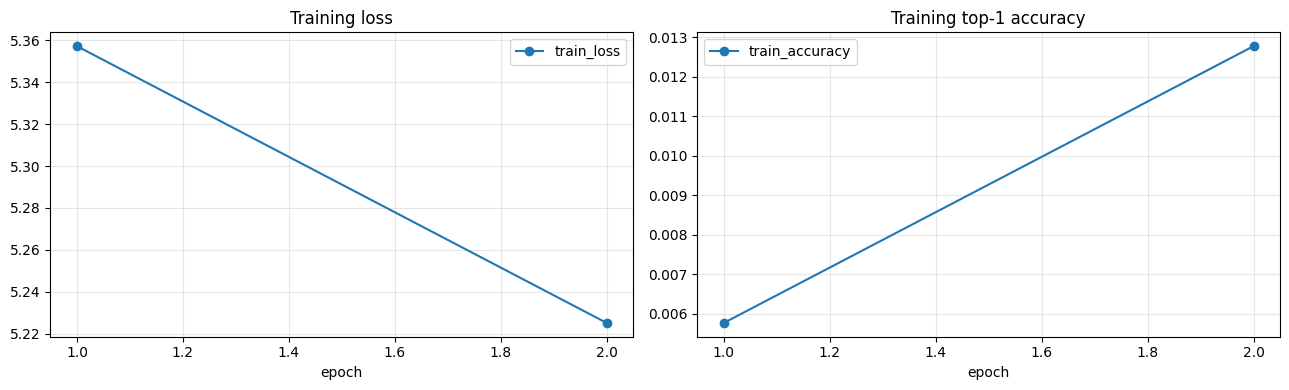

,epoch,train_loss,train_accuracy,learning_rate,fusion_mode
0,1,5.357248,0.005771,0.00005,feature_fusion
1,2,5.225104,0.012770,0.00000,feature_fusion


In [13]:
if 'history_df' not in globals():
    history_df = pd.read_csv(OUT_PUT_DIR / 'training_history.csv')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
history_df.plot(x='epoch', y='train_loss', ax=axes[0], marker='o', markevery=max(1, len(history_df) // 10), title='Training loss')
history_df.plot(x='epoch', y='train_accuracy', ax=axes[1], marker='o', markevery=max(1, len(history_df) // 10), title='Training top-1 accuracy')
for axis in axes:
    axis.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
display(history_df.tail())


## 7. Official test accuracy

Cell này load final checkpoint; nếu final chưa có vì training bị dừng giữa chừng thì dùng `checkpoint_last.pt`. Metric chính là `test_accuracy`, tương ứng `Acc` của Cars trong Table 2.


In [14]:
def macro_f1_score_np(y_true, y_pred, num_classes):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    f1_values = []
    for class_id in range(num_classes):
        tp = np.sum((y_true == class_id) & (y_pred == class_id))
        fp = np.sum((y_true != class_id) & (y_pred == class_id))
        fn = np.sum((y_true == class_id) & (y_pred != class_id))
        denom = 2 * tp + fp + fn
        f1_values.append(0.0 if denom == 0 else (2 * tp) / denom)
    return float(np.mean(f1_values))


def evaluate_context_model(network, loader, top_k=TOP_K):
    network.eval()
    total_loss = 0.0
    all_targets = []
    all_predictions = []
    rows = []
    top_k = min(top_k, NUM_CLASSES)
    with torch.inference_mode():
        for query_images, context_images, labels, file_names, context_file_names, context_labels in tqdm(loader, desc='test', leave=False):
            query_images = query_images.to(DEVICE, non_blocking=True)
            context_images = context_images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            logits = network(query_images, context_images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1).cpu()
            values, indices = torch.topk(probs, k=top_k, dim=1)
            predictions = logits.argmax(dim=1).detach().cpu()
            labels_cpu = labels.detach().cpu()
            total_loss += loss.item() * query_images.size(0)
            all_targets.extend(labels_cpu.tolist())
            all_predictions.extend(predictions.tolist())
            for fname, ctx_fname, ctx_label, label, pred, value_row, index_row in zip(file_names, context_file_names, context_labels, labels_cpu, predictions, values, indices):
                label_id = int(label)
                pred_id = int(pred)
                context_label_id = int(ctx_label)
                top_class_ids = [int(index) for index in index_row]
                rows.append({
                    'fname': fname,
                    'true_class_id': label_id,
                    'true_car_name': class_names[label_id],
                    'context_fname': ctx_fname,
                    'context_class_id': context_label_id,
                    'context_car_name': class_names[context_label_id],
                    'predicted_class_id': pred_id,
                    'predicted_car_name': class_names[pred_id],
                    'correct': bool(pred_id == label_id),
                    'confidence': float(value_row[0]),
                    'top_k_class_ids': '|'.join(str(index) for index in top_class_ids),
                    'top_k_car_names': '|'.join(class_names[index] for index in top_class_ids),
                    'top_k_probabilities': '|'.join(f'{float(value):.6f}' for value in value_row),
                })
    y_true = np.asarray(all_targets)
    y_pred = np.asarray(all_predictions)
    return {
        'test_loss': total_loss / len(loader.dataset),
        'test_accuracy': float(np.mean(y_true == y_pred)),
        'test_macro_f1': macro_f1_score_np(y_true, y_pred, NUM_CLASSES),
        'predictions': pd.DataFrame(rows),
    }


evaluation_checkpoint_path = checkpoint_path if checkpoint_path.is_file() else last_checkpoint_path
saved_checkpoint = torch.load(evaluation_checkpoint_path, map_location=DEVICE)
model.load_state_dict(saved_checkpoint['model_state_dict'])
model.eval()
print('Loaded checkpoint for evaluation:', evaluation_checkpoint_path.resolve())

results = evaluate_context_model(model, test_loader, top_k=TOP_K)
test_prediction_df = results.pop('predictions')
test_prediction_df.to_csv(OUT_PUT_DIR / 'test_predictions.csv', index=False)
metrics = {
    'method': 'Random Context Retrieval',
    'test_accuracy': results['test_accuracy'],
    'test_loss': results['test_loss'],
    'test_macro_f1': results['test_macro_f1'],
    'num_classes': NUM_CLASSES,
    'standard_train_size': len(train_dataset),
    'standard_test_size': len(test_dataset),
    'architecture': BACKBONE_NAME,
    'pretraining': 'DINOv3',
    'fusion_mode': getattr(model, 'active_fusion_mode', saved_checkpoint.get('fusion_mode', 'unknown')),
    'image_size': IMAGE_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'seed': SEED,
    'use_bbox_crop': USE_BBOX_CROP,
    'candidate_pool_fraction': CANDIDATE_POOL_FRACTION,
    'candidate_pool_size': len(candidate_df),
    'checkpoint': str(evaluation_checkpoint_path),
}
with open(OUT_PUT_DIR / 'metrics.json', 'w', encoding='utf-8') as file:
    json.dump(metrics, file, ensure_ascii=False, indent=2)
print(f"test_accuracy: {metrics['test_accuracy']:.4f} ({metrics['test_accuracy'] * 100:.2f}%)")
print(f"test_loss: {metrics['test_loss']:.4f}")
print(f"test_macro_f1: {metrics['test_macro_f1']:.4f}")
print('Saved test predictions:', (OUT_PUT_DIR / 'test_predictions.csv').resolve())
print('Saved metrics:', (OUT_PUT_DIR / 'metrics.json').resolve())
display(test_prediction_df.head())


Loaded checkpoint for evaluation: /content/outputs/baseline_random_context_ret_cars/final_random_context_ret_dinov3_vits16_cars.pt


test:   0%|          | 0/126 [00:00<?, ?it/s]

test_accuracy: 0.0179 (1.79%)
test_loss: 5.1524
test_macro_f1: 0.0061
Saved test predictions: /content/outputs/baseline_random_context_ret_cars/test_predictions.csv
Saved metrics: /content/outputs/baseline_random_context_ret_cars/metrics.json


,fname,true_class_id,true_car_name,context_fname,context_class_id,context_car_name,predicted_class_id,predicted_car_name,correct,confidence,top_k_class_ids,top_k_car_names,top_k_probabilities
0,00001.jpg,180,Suzuki Aerio Sedan 2007,05232.jpg,191,Volkswagen Beetle Hatchback 2012,44,Bugatti Veyron 16.4 Convertible 2009,False,0.010831,44|185|50|165|18,Bugatti Veyron 16.4 Convertible 2009|Toyota Se...,0.010831|0.009774|0.009294|0.008602|0.008492
1,00002.jpg,102,Ferrari 458 Italia Convertible 2012,05439.jpg,67,Chevrolet TrailBlazer SS 2009,103,Ferrari 458 Italia Coupe 2012,False,0.030228,103|101|102|124|54,Ferrari 458 Italia Coupe 2012|Ferrari Californ...,0.030228|0.029538|0.028563|0.028304|0.023712
2,00003.jpg,144,Jeep Patriot SUV 2012,05905.jpg,118,GMC Savana Van 2012,118,GMC Savana Van 2012,False,0.010197,118|142|161|47|148,GMC Savana Van 2012|Isuzu Ascender SUV 2008|Me...,0.010197|0.008859|0.008526|0.008463|0.008244
3,00004.jpg,186,Toyota Camry Sedan 2012,03975.jpg,42,Bentley Continental GT Coupe 2007,143,Jaguar XK XKR 2012,False,0.010304,143|34|44|75|195,Jaguar XK XKR 2012|BMW M5 Sedan 2010|Bugatti V...,0.010304|0.009240|0.009163|0.008761|0.008530
4,00005.jpg,184,Tesla Model S Sedan 2012,07275.jpg,190,Volkswagen Golf Hatchback 1991,112,Ford F-150 Regular Cab 2012,False,0.009702,112|147|50|75|73,Ford F-150 Regular Cab 2012|Jeep Grand Cheroke...,0.009702|0.008554|0.008406|0.008342|0.008316


## 8. Inference và load checkpoint

Dùng hàm này để test nhanh một ảnh với context ngẫu nhiên từ candidate pool, hoặc load model ở phiên chạy khác.


In [15]:
def predict_one_image_with_random_context(image_path, context_image_path=None, network=model, top_k=TOP_K, seed=SEED):
    image_path = Path(image_path)
    if context_image_path is None:
        rng = np.random.default_rng(seed)
        context_row = candidate_df.iloc[int(rng.integers(0, len(candidate_df)))]
        context_image_path = Path(context_row['image_path'])
        context_name = class_names[int(context_row['class_id'])]
    else:
        context_image_path = Path(context_image_path)
        context_name = None
    query_image = eval_transform(Image.open(image_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    context_image = eval_transform(Image.open(context_image_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    network.eval()
    with torch.inference_mode():
        logits = network(query_image, context_image)
        probs = torch.softmax(logits, dim=1)[0]
        values, indices = torch.topk(probs, k=min(top_k, NUM_CLASSES))
    result = pd.DataFrame({
        'rank': np.arange(1, len(indices) + 1),
        'class_id': [int(index) for index in indices.cpu()],
        'car_name': [class_names[int(index)] for index in indices.cpu()],
        'probability': [float(value) for value in values.cpu()],
    })
    print('Query image:', image_path)
    print('Context image:', context_image_path)
    if context_name is not None:
        print('Context label:', context_name)
    return result


def load_random_context_model_for_inference(checkpoint_file, device=DEVICE):
    saved = torch.load(checkpoint_file, map_location=device)
    loaded_model = DinoV3RandomContextClassifier(
        repo_dir=saved.get('dinov3_repo_dir', DINOV3_REPO_DIR),
        model_name=saved.get('dinov3_model_name', saved.get('architecture', DINOV3_MODEL_NAME)),
        weights=saved.get('dinov3_weights', resolve_dinov3_weights()),
        num_classes=len(saved['class_names']),
        feature_dim=saved.get('feature_dim', FEATURE_DIM),
    )
    loaded_model.load_state_dict(saved['model_state_dict'])
    loaded_model.to(device).eval()
    return loaded_model, saved['class_names']

print('Final checkpoint:', checkpoint_path.resolve())
print('Latest checkpoint:', last_checkpoint_path.resolve())
print('Method:', 'Random Context Retrieval')


Final checkpoint: /content/outputs/baseline_random_context_ret_cars/final_random_context_ret_dinov3_vits16_cars.pt
Latest checkpoint: /content/outputs/baseline_random_context_ret_cars/checkpoint_last.pt
Method: Random Context Retrieval


## 9. Ghi chú benchmark

- Method này tương ứng hàng **Random Context Ret.** trong Table 2.
- Candidate pool lấy từ 20% train split.
- Không dùng validation split và không dùng test để chọn epoch.
- Metric chính cho Cars là `test_accuracy`.
- Những file nên giữ để so sánh method: `metrics.json`, `training_history.csv`, `test_predictions.csv`, `candidate_pool.csv`, `test_random_context_pairs.csv`, `checkpoint_last.pt`, và final checkpoint.
